In [51]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

In [52]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [56]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



In [57]:
#let's label the samples based on their tissue or origin
conditions = [adata.obs.site.str.contains("lung|bronchus"), adata.obs.site.str.contains("cervical"), adata.obs.site.str.contains("bile")]
adata.obs["tissue"] = np.select(condlist=conditions, choicelist=["Lung", "Cervix", "Bile"])

In [58]:
#Let's exclude one sample
adata = adata[~adata.obs["site"].str.contains("primary")]

In [59]:
#log transform adata
sc.pp.log1p(adata)
sc.pp.scale(adata)
adata.X = adata.X.astype(np.float32).copy()

/Users/jawadalaaedeen/Desktop/PhD/NMC/nmc_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:404: UserWarning:

Received a view of an AnnData. Making a copy.



In [60]:
sc.pp.combat(adata, key="exp_name", inplace=True)

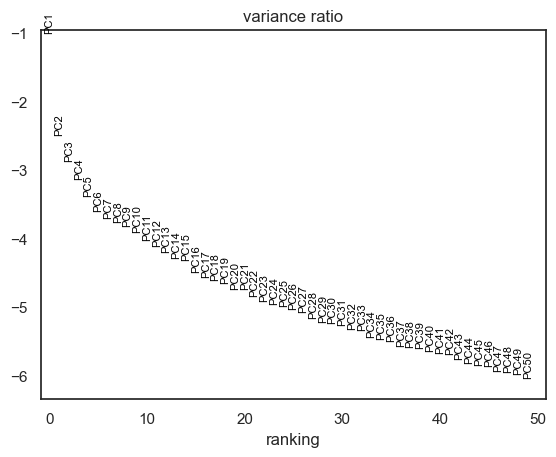

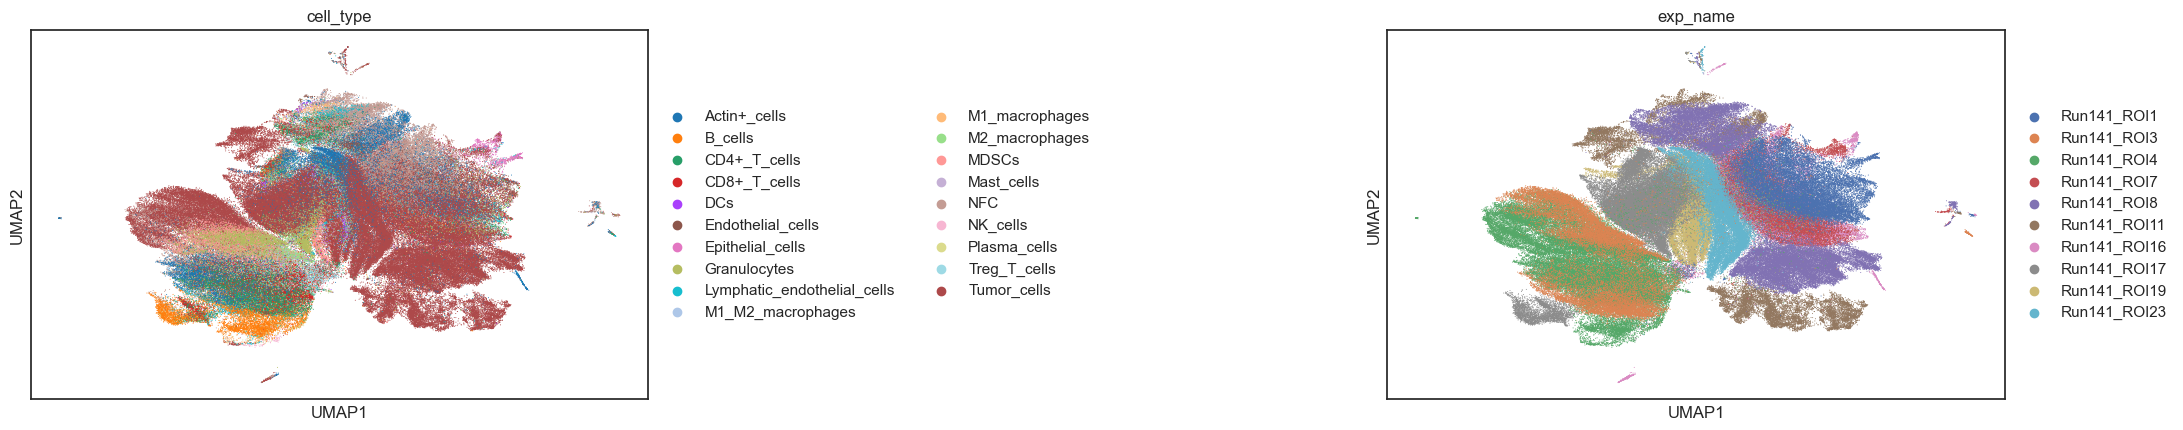

In [61]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
#give more space for firt umap plot
sc.pl.umap(
    adata,
    color=["cell_type", "exp_name"],
    # Setting a smaller point size to get prevent overlap
    size=2,
    ncols=2,
    #give more space to first umap plot
    wspace=1,
)

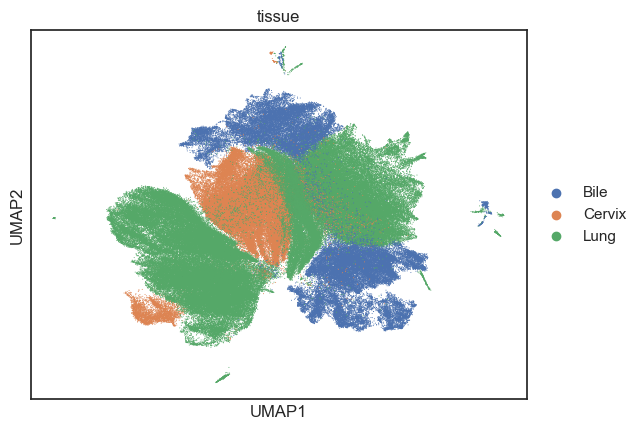

In [63]:
sc.pl.umap(
    adata,
    color=["tissue"],
    # Setting a smaller point size to get prevent overlap
    size=2,
    #give more space to first umap plot
    wspace=1,
)